In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("16P.csv", encoding="latin1") 
df.head()

,Response Id,You regularly make new friends.,You spend a lot of your free time exploring various random topics that pique your interest,Seeing other people cry can easily make you feel like you want to cry too,You often make a backup plan for a backup plan.,"You usually stay calm, even under a lot of pressure","At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",You prefer to completely finish one project before starting another.,You are very sentimental.,You like to use organizing tools like schedules and lists.,...,You believe that pondering abstract philosophical questions is a waste of time.,"You feel more drawn to places with busy, bustling atmospheres than quiet, intimate places.",You know at first glance how someone is feeling.,You often feel overwhelmed.,You complete things methodically without skipping over any steps.,You are very intrigued by things labeled as controversial.,You would pass along a good opportunity if you thought someone else needed it more.,You struggle with deadlines.,You feel confident that things will work out for you.,Personality
0,0,0,0,0,0,0,1,1,0,0,...,0,0,0,-1,0,0,0,0,0,ENFP
1,1,0,0,-2,-3,-1,2,-2,0,3,...,0,-2,0,2,0,-1,-1,-1,3,ISFP
2,2,0,0,2,0,-1,2,0,0,1,...,0,2,0,2,-1,0,1,2,1,INFJ
3,3,0,-1,3,-1,0,0,-2,0,-2,...,0,0,-1,-1,0,1,0,-2,-1,ISTP
4,4,0,0,-1,0,2,-1,-2,0,1,...,0,1,0,2,0,1,-1,2,-1,ENFJ


In [3]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum().sum())
print("\nTarget classes:\n", df["Personality"].value_counts())

Shape: (59999, 62)

Columns:
 ['Response Id', 'You regularly make new friends.', 'You spend a lot of your free time exploring various random topics that pique your interest', 'Seeing other people cry can easily make you feel like you want to cry too', 'You often make a backup plan for a backup plan.', 'You usually stay calm, even under a lot of pressure', 'At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know', 'You prefer to completely finish one project before starting another.', 'You are very sentimental.', 'You like to use organizing tools like schedules and lists.', 'Even a small mistake can cause you to doubt your overall abilities and knowledge.', 'You feel comfortable just walking up to someone you find interesting and striking up a conversation.', 'You are not too interested in discussing various interpretations and analyses of creative works.', 'You are more inclined to follow your head than your heart.', 'You usuall

In [4]:
target_col = "Personality"
id_col = "Response Id"

question_cols = [col for col in df.columns if col not in [id_col, target_col]]

print("Number of question columns:", len(question_cols))
print(question_cols[:5])

Number of question columns: 60
['You regularly make new friends.', 'You spend a lot of your free time exploring various random topics that pique your interest', 'Seeing other people cry can easily make you feel like you want to cry too', 'You often make a backup plan for a backup plan.', 'You usually stay calm, even under a lot of pressure']


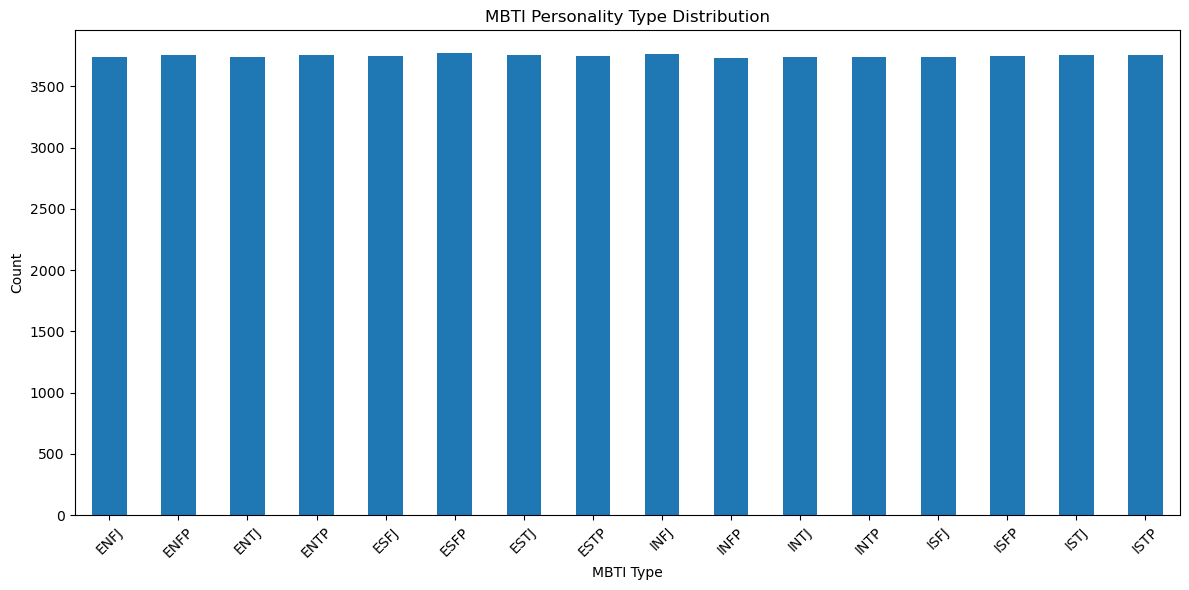

In [5]:
plt.figure(figsize=(12,6))
df["Personality"].value_counts().sort_index().plot(kind="bar")
plt.title("MBTI Personality Type Distribution")
plt.xlabel("MBTI Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

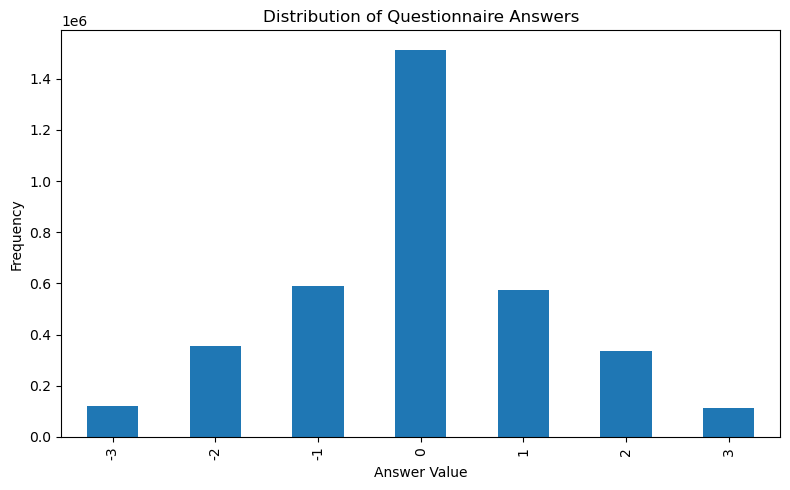

In [6]:
all_answers = df[question_cols].values.flatten()

plt.figure(figsize=(8,5))
pd.Series(all_answers).value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Questionnaire Answers")
plt.xlabel("Answer Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
df[question_cols].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
You regularly make new friends.,59999.0,-0.000867,0.365701,-2.0,0.0,0.0,0.0,1.0
You spend a lot of your free time exploring various random topics that pique your interest,59999.0,-0.000467,0.364652,-1.0,0.0,0.0,0.0,1.0
Seeing other people cry can easily make you feel like you want to cry too,59999.0,0.000267,1.527343,-3.0,-1.0,0.0,1.0,3.0
You often make a backup plan for a backup plan.,59999.0,-0.232887,1.502173,-3.0,-1.0,0.0,1.0,3.0
"You usually stay calm, even under a lot of pressure",59999.0,-0.175653,1.502999,-3.0,-1.0,0.0,1.0,3.0
"At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",59999.0,0.005317,1.521413,-3.0,-1.0,0.0,1.0,3.0
You prefer to completely finish one project before starting another.,59999.0,-0.476558,1.445931,-3.0,-2.0,-1.0,0.0,3.0
You are very sentimental.,59999.0,-0.000550,0.367361,-1.0,0.0,0.0,0.0,2.0
You like to use organizing tools like schedules and lists.,59999.0,0.126819,1.537329,-3.0,-1.0,0.0,1.0,3.0
Even a small mistake can cause you to doubt your overall abilities and knowledge.,59999.0,-0.003283,0.367347,-1.0,0.0,0.0,0.0,1.0


In [8]:
group_means = df.groupby("Personality")[question_cols].mean()
group_means.head()

,You regularly make new friends.,You spend a lot of your free time exploring various random topics that pique your interest,Seeing other people cry can easily make you feel like you want to cry too,You often make a backup plan for a backup plan.,"You usually stay calm, even under a lot of pressure","At social events, you rarely try to introduce yourself to new people and mostly talk to the ones you already know",You prefer to completely finish one project before starting another.,You are very sentimental.,You like to use organizing tools like schedules and lists.,Even a small mistake can cause you to doubt your overall abilities and knowledge.,...,You would love a job that requires you to work alone most of the time.,You believe that pondering abstract philosophical questions is a waste of time.,"You feel more drawn to places with busy, bustling atmospheres than quiet, intimate places.",You know at first glance how someone is feeling.,You often feel overwhelmed.,You complete things methodically without skipping over any steps.,You are very intrigued by things labeled as controversial.,You would pass along a good opportunity if you thought someone else needed it more.,You struggle with deadlines.,You feel confident that things will work out for you.
Personality,,,,,,,,,,,,,,,,,,,,,
ENFJ,0.006946,-0.004007,0.006412,0.955651,-0.011755,-0.943361,-0.923324,0.008282,0.000534,-0.005076,...,-0.002137,0.004542,-0.960192,0.000534,0.978092,0.001870,0.002939,-0.029923,-0.041945,0.016564
ENFP,0.002394,0.004521,0.972340,0.956649,-0.006915,0.043617,-0.055053,-0.006383,-0.932713,0.001330,...,0.001596,-0.010106,-0.032181,-0.006915,-0.933245,-0.007181,-0.013032,0.953723,0.934840,0.005851
ENTJ,0.005619,0.005887,-0.942200,-0.924806,0.983409,0.945143,-0.035590,0.003746,0.032914,0.000000,...,-0.009366,-0.001873,0.021408,-0.003746,-0.011239,-0.007493,0.001338,0.014985,-0.015788,-0.939791
ENTP,0.000532,0.002660,-0.953723,0.934309,-0.963032,-0.943617,-0.951596,-0.009309,0.078457,-0.007447,...,-0.002128,-0.005053,0.925532,-0.004787,-0.016755,0.012500,0.002394,0.981383,-0.967819,-0.930851
ESFJ,-0.007475,-0.012547,0.005873,0.037373,0.938868,0.020288,-0.933796,-0.003737,-0.023225,-0.011212,...,-0.004004,-0.004004,0.959690,0.001602,0.950881,-0.003470,-0.003203,0.944474,0.012280,0.008275


In [9]:
df["E_I"] = df["Personality"].apply(lambda x: 1 if x[0] == "E" else 0)
df["S_N"] = df["Personality"].apply(lambda x: 1 if x[1] == "S" else 0)
df["T_F"] = df["Personality"].apply(lambda x: 1 if x[2] == "T" else 0)
df["J_P"] = df["Personality"].apply(lambda x: 1 if x[3] == "J" else 0)

df[["Personality", "E_I", "S_N", "T_F", "J_P"]].head()

,Personality,E_I,S_N,T_F,J_P
0,ENFP,1,0,0,0
1,ISFP,0,1,0,0
2,INFJ,0,0,0,1
3,ISTP,0,1,1,0
4,ENFJ,1,0,0,1


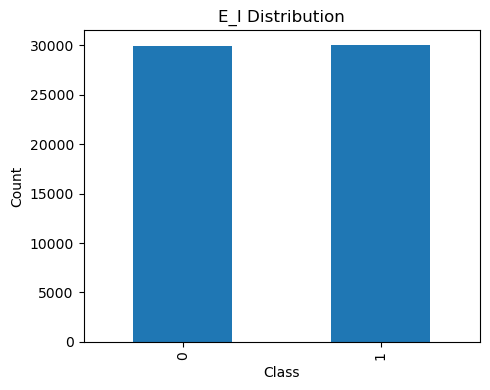

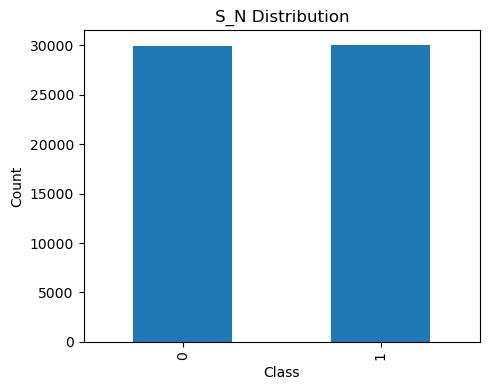

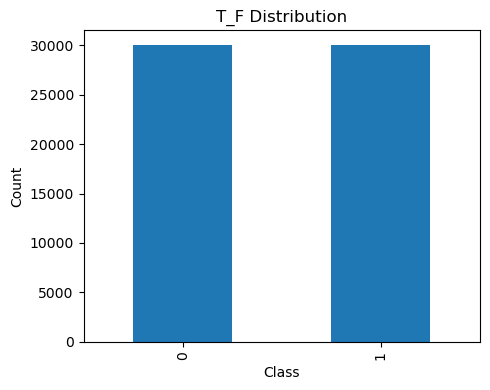

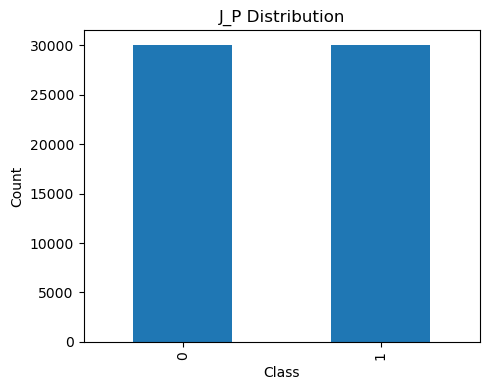

In [10]:
traits = ["E_I", "S_N", "T_F", "J_P"]

for trait in traits:
    plt.figure(figsize=(5,4))
    df[trait].value_counts().sort_index().plot(kind="bar")
    plt.title(f"{trait} Distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [12]:
X = df[question_cols]

traits = ["E_I", "S_N", "T_F", "J_P"]
models = {}
results = {}

In [13]:
for trait in traits:
    print(f"\n======================")
    print(f"Training for {trait}")
    print(f"======================")
    
    y = df[trait]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    models[trait] = model
    results[trait] = acc


Training for E_I
Accuracy: 0.9735

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      5995
           1       0.97      0.98      0.97      6005

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000

Confusion Matrix:
[[5818  177]
 [ 141 5864]]

Training for S_N
Accuracy: 0.9751666666666666

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5996
           1       0.98      0.97      0.98      6004

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000

Confusion Matrix:
[[5874  122]
 [ 176 5828]]

Training for T_F
Accuracy: 0.9705

Classification Report:
              precision    recall  f1-score   support

           0

In [14]:
print("\n==== FINAL ACCURACIES ====")
for trait, acc in results.items():
    print(f"{trait}: {acc:.4f}")


==== FINAL ACCURACIES ====
E_I: 0.9735
S_N: 0.9752
T_F: 0.9705
J_P: 0.9710


In [ ]:
# Re-split once (same split for all traits)
X_train, X_test, y_train_full, y_test_full = train_test_split(
    X, df["Personality"],
    test_size=0.2,
    random_state=42,
    stratify=df["Personality"]
)

# Predict MBTI from 4 models
pred_mbti = []

for i in range(len(X_test)):
    row = X_test.iloc[i:i+1]

    mbti = ""
    mbti += "E" if models["E_I"].predict(row)[0] == 1 else "I"
    mbti += "S" if models["S_N"].predict(row)[0] == 1 else "N"
    mbti += "T" if models["T_F"].predict(row)[0] == 1 else "F"
    mbti += "J" if models["J_P"].predict(row)[0] == 1 else "P"

    pred_mbti.append(mbti)

# Compare with true labels
true_mbti = y_test_full.values

full_accuracy = sum(p == t for p, t in zip(pred_mbti, true_mbti)) / len(true_mbti)

print("\n======================")
print("FULL MBTI ACCURACY:", full_accuracy)
print("======================")

Exception ignored in thread started by <bound method Thread._bootstrap of <DummyProcess(Thread-30674 (worker), initial daemon)>>:
MemoryError: 


In [ ]:
for i in range(10):
    print(f"Pred: {pred_mbti[i]} | True: {true_mbti[i]}")

In [ ]:
print(question_cols)